# Titulo del Proyecto
### Modelo "Insolation Forest", para detectar anomalias en el pago del impuesto de ReteICA en el municipio de La Unión, Valle del Cauca, Colombia.
## Integrantes:
- Juan Jose Mayorga
- Wilson Russi
- Luis Delio Salazar
- Juan David Velez C
## Fecha de entrega: 11 de Abril de 2026
### Enlace al repositorio: ['https://github.com/usuario/repositorio'] (Enlace al repositorio de GitHub)

# Problema del Negocio
El problema del negocio que se busca resolver es la detección de anomalías en el pago del impuesto de ReteICA en el municipio de La Unión, Valle del Cauca, Colombia. El objetivo es identificar patrones inusuales en los datos de pago que puedan indicar posibles fraudes o errores en el proceso de pago del impuesto. Esto es crucial para mejorar la eficiencia en la recaudación de impuestos y garantizar que se cumplan las obligaciones fiscales de manera justa y equitativa.

Buscando implementar una cultura de pago en todos los contribuyentes, evidenciando que la entidad cuenta con herramientas tecnológicas que permiten detectar anomalías en el pago del impuesto de ReteICA, lo que a su vez contribuye a mejorar la eficiencia operativa de la entidad y a garantizar el cumplimiento de las obligaciones fiscales por parte de los contribuyentes. Además, se busca fomentar la transparencia y la confianza en el sistema tributario, lo que puede incentivar a más contribuyentes a cumplir con sus obligaciones fiscales de manera voluntaria. En última instancia, esto puede contribuir a aumentar los ingresos para el municipio y mejorar la calidad de vida de sus habitantes.

In [421]:
# Instalar dependencias:

import os
import numpy as np
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, accuracy_score, classification_report
import pandas as pd
from pymongo import MongoClient

# ─── Configuración ────────────────────────────────────────────────────────────
MONGO_URI         = os.getenv("MONGO_URI", None)
DB_NAME           = os.getenv("DB_NAME",   None)
COLLECTION_NAME   = os.getenv("COLLECTION_NAME", None)
ANOMALY_THRESHOLD = float(os.getenv("ANOMALY_THRESHOLD", "0.62"))


In [422]:
# ─── Conexión a MongoDB ───────────────────────────────────────────────────────
client = MongoClient(MONGO_URI)
db = client[DB_NAME]
collection = db[COLLECTION_NAME]

# ─── Consulta de Datos ───────────────────────────────────────────────────────
# Data = list(collection.find({"status": "", "vigencia": {"$in": ["2025", "2026"]}}, {"_id": 0, "nit": 1, "vigencia": 1, "mes": 1, "ren26": 1, "creacion": 1}).sort("creacion", -1))
Data = list(collection.find({"status": ""}, {"_id": 0, "nit": 1, "vigencia": 1, "mes": 1, "ren26": 1, "creacion": 1}).sort("creacion", -1))
print(f"Datos obtenidos: {len(Data)} registros")
print(f"Fecha de consulta: {datetime.now().isoformat()}")

# ─── Preprocesamiento de Datos ───────────────────────────────────────────────
# Convertir a DataFrame para facilitar el manejo
df = pd.DataFrame(Data)

Datos obtenidos: 5727 registros
Fecha de consulta: 2026-04-02T16:01:12.035820


In [423]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5727 entries, 0 to 5726
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   vigencia  5727 non-null   object
 1   mes       5727 non-null   object
 2   nit       5727 non-null   object
 3   ren26     5727 non-null   object
 4   creacion  5727 non-null   object
dtypes: object(5)
memory usage: 223.8+ KB


## Donde vienen los datos
- Los datos utilizados para este proyecto provienen del Departamento Administrativo de Hacienda del municipio de La Unión, Valle del Cauca, Colombia. Estos datos contienen información sobre los pagos del impuesto de ReteICA realizados por los contribuyentes en diferentes vigencias y meses. La información se ha recopilado a través de los registros de pago del impuesto, que incluyen detalles como el número de identificación tributaria (Nit), el monto pagado, la fecha de creación del registro, entre otros. Estos datos son fundamentales para entrenar el modelo de detección de anomalías y evaluar su desempeño en la identificación de patrones inusuales en los pagos del impuesto de ReteICA.

## Descripción de Columnas del Dataset
- **Vigencia**: Año fiscal al que corresponde el pago del impuesto.
- **Mes**: Mes en el que se realizó el pago del impuesto.
- **Nit**: Número de Identificación Tributaria del contribuyente.
- **ren26**: Monto pagado por el contribuyente en la vigencia.
- **creacion**: Fecha de creación del registro.

# EDA (Exploración de Datos)

## Preprocesamiento de Datos

- Valores nulos y  tipos de datos int, datetime, etc. 
- Convertir las columnas a los tipos de datos adecuados (int, datetime, etc.) y manejar los valores nulos si es necesario.


In [424]:
columns_to_int = ['nit', 'vigencia', 'mes', 'ren26']
for col in columns_to_int:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    df['creacion'] = pd.to_datetime(df['creacion'], errors='coerce').fillna(pd.Timestamp(0)).astype('datetime64[ns]')
print("Datos preprocesados:")
print(df.head())


Datos preprocesados:
   vigencia  mes         nit    ren26            creacion
0      2024   12  1112632120  1571000 2026-03-22 15:40:21
1      2024   11  1112632120   471000 2026-03-20 15:13:54
2      2026    4  1112632120    10000 2026-03-20 15:10:57
3      2024   12  1112632120  1471000 2026-03-20 15:03:15
4      2026    2   891900968  9133000 2026-03-18 12:59:41


In [425]:
print('✅ Variables convertidas a numérico')
df.info()

✅ Variables convertidas a numérico
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5727 entries, 0 to 5726
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   vigencia  5727 non-null   int64         
 1   mes       5727 non-null   int64         
 2   nit       5727 non-null   int64         
 3   ren26     5727 non-null   int64         
 4   creacion  5727 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(4)
memory usage: 223.8 KB


### Estadísticas descriptivas

In [426]:
# Estadísticas descriptivas Validar Transformaciones
df.describe().transpose().round(0)

,count,mean,min,25%,50%,75%,max,std
vigencia,5727.0,2023.942029,2020.0,2023.0,2024.0,2025.0,2026.0,0.892859
mes,5727.0,6.618823,1.0,4.0,6.0,10.0,12.0,3.507412
nit,5727.0,734946572.783133,2472220.0,800167643.0,890707192.0,900481866.0,1193031848.0,318999304.550018
ren26,5727.0,1396207.438624,0.0,50000.0,383000.0,1295000.0,56802000.0,3411205.461278
creacion,5727,2024-07-13 06:58:12.251789824,2022-12-09 14:22:48,2023-10-11 09:37:24,2024-06-13 16:06:09,2025-03-14 18:20:23,2026-03-22 15:40:21,NaN


# Graficos de distribución y correlación

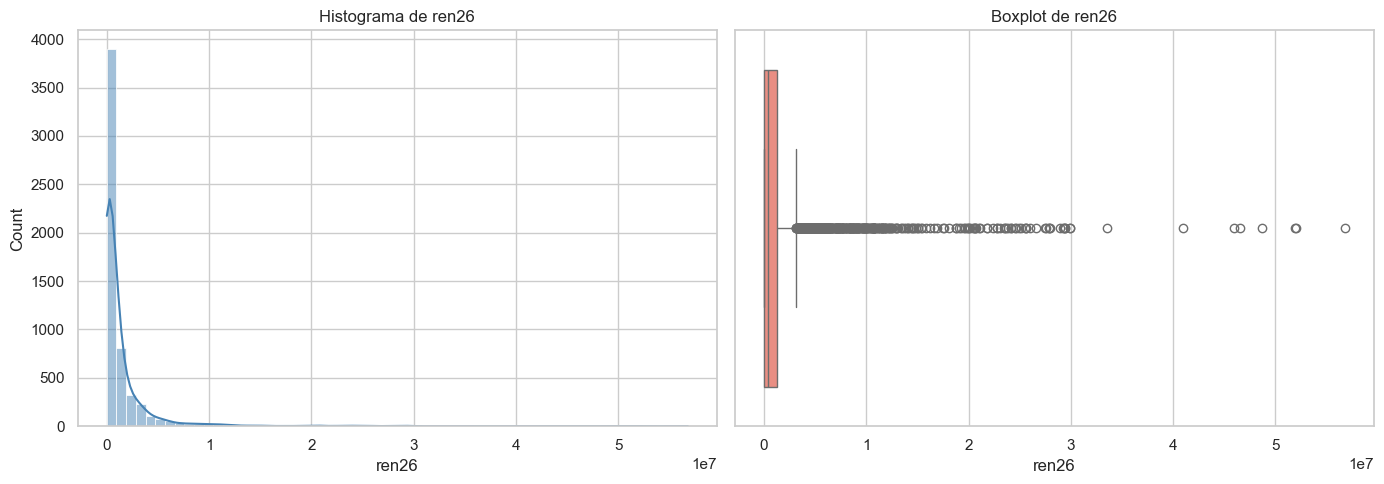

In [427]:
sns.set(style="whitegrid", context="notebook")

# =========================
# Distribución de 'ren26'
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["ren26"], bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Histograma de ren26")
axes[0].set_xlabel("ren26")

sns.boxplot(x=df["ren26"], ax=axes[1], color="salmon")
axes[1].set_title("Boxplot de ren26")
axes[1].set_xlabel("ren26")

plt.tight_layout()
plt.show()



### Explicación de los gráficos y su interpretación
- Lo que se ve en las gráficas (Análisis Técnico) Asimetría fuertemente positiva (Sesgo a la derecha): El histograma muestra que la inmensa mayoría de los registros se agrupan en el primer bin, muy cerca de cero. La curva cae drásticamente de inmediato.Compresión de los cuartiles: En el boxplot, la caja (que representa el 50% central de los datos) es tan estrecha y está tan pegada a la izquierda que la mediana y los percentiles bajos son casi indistinguibles.Presencia extrema de valores atípicos (Outliers): El boxplot revela una larga "cola" de puntos individuales que se extienden hacia la derecha, alcanzando valores de hasta casi 60 millones ($6 \times 10^7$).

- Qué decirle al negocio (Interpretación y Estrategia)

1. El volumen operativo está en los montos pequeños
La gran mayoría de las transacciones o entidades sujetas a la retención de ICA en esta base de datos generan montos muy bajos. El esfuerzo operativo diario (procesamiento, facturación, etc.) se está gastando en procesar miles de registros que individualmente aportan poco al total del impuesto.

2. Altísima concentración de valor (Efecto Pareto)
Aunque la mayoría de los registros son de bajo valor, el negocio depende de un grupo muy reducido de transacciones o clientes que generan retenciones de ReteICA extremadamente altas (esos puntos solitarios que llegan hasta los 60 millones). Esto indica que unos pocos "grandes contribuyentes" o contratos corporativos masivos mueven la aguja financiera.

3. Alerta de Calidad de Datos (Data Quality)
Debes recomendar una validación de los valores extremos. Es crucial preguntar al negocio: "¿Es normal en nuestra operación tener retenciones de ICA individuales de 40, 50 o 60 millones?" Si la respuesta es no, esos outliers podrían ser errores de digitación (por ejemplo, un cero de más) o fallas en el cálculo del ERP que deben corregirse antes de cualquier declaración tributaria.

4. Los promedios no sirven aquí
Puedes advertirles que usar un "promedio" (la media) para proyectar o analizar el ReteICA en este conjunto de datos será engañoso. Los montos extremos tirarán el promedio hacia arriba, ocultando la realidad de que la transacción típica es muy cercana a cero. Es mejor hablar de medianas o rangos.


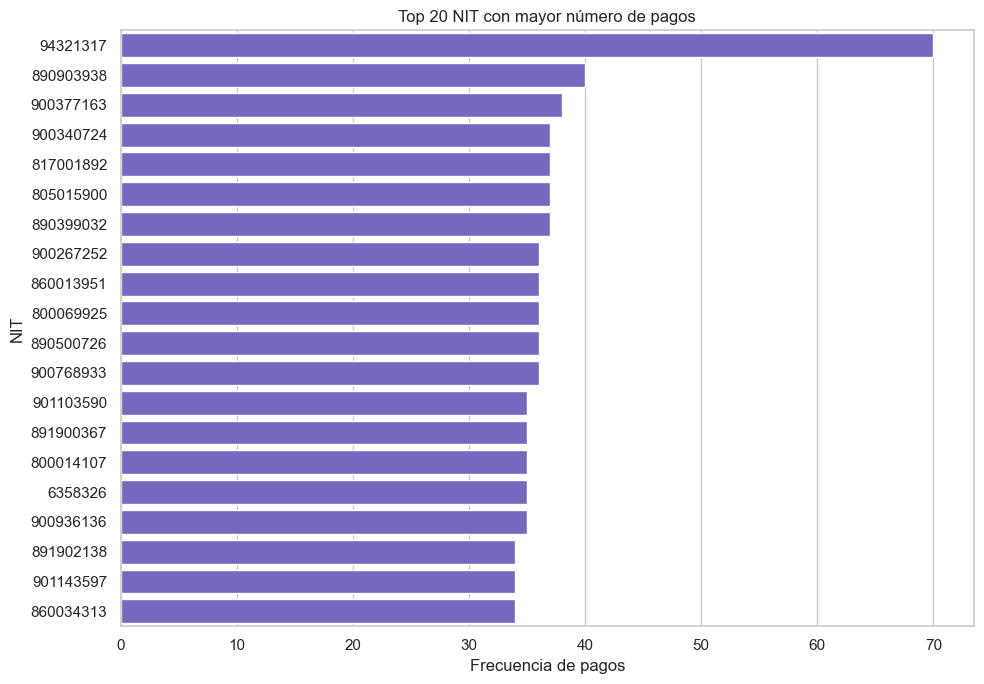

NITs con frecuencia inusual (>= percentil 99): 7


,frecuencia_pagos
nit,
94321317,70
890903938,40
900377163,38
900340724,37
817001892,37
805015900,37
890399032,37


In [428]:
# =========================
# Frecuencia de pagos por NIT
# =========================
freq_nit = df["nit"].value_counts()
top_nits = freq_nit.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_nits.values, y=top_nits.index.astype(str), color="slateblue")
plt.title("Top 20 NIT con mayor número de pagos")
plt.xlabel("Frecuencia de pagos")
plt.ylabel("NIT")
plt.tight_layout()
plt.show()

umbral_inusual = freq_nit.quantile(0.99)
nits_inusuales = freq_nit[freq_nit >= umbral_inusual].sort_values(ascending=False)

print(f"NITs con frecuencia inusual (>= percentil 99): {len(nits_inusuales)}")
display(nits_inusuales.to_frame(name="frecuencia_pagos"))

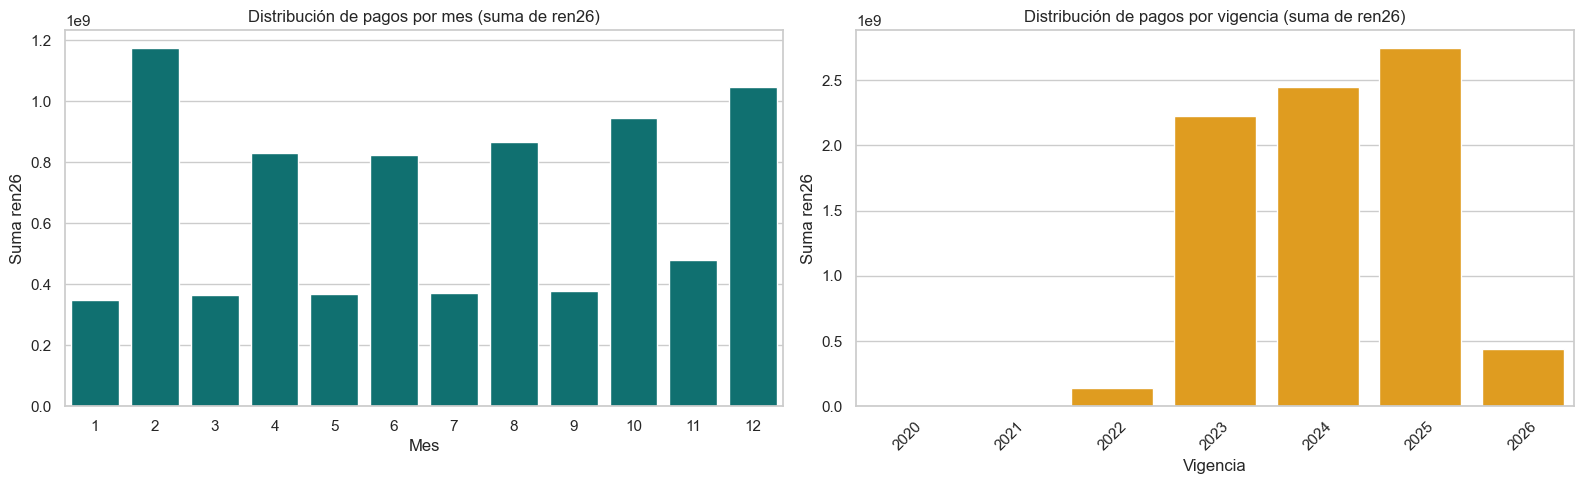

In [429]:
# =========================
# Variables categóricas
# =========================
pagos_mes = df.groupby("mes")["ren26"].sum().sort_index()
pagos_vigencia = df.groupby("vigencia")["ren26"].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=pagos_mes.index, y=pagos_mes.values, ax=axes[0], color="teal")
axes[0].set_title("Distribución de pagos por mes (suma de ren26)")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Suma ren26")

sns.barplot(x=pagos_vigencia.index.astype(str), y=pagos_vigencia.values, ax=axes[1], color="orange")
axes[1].set_title("Distribución de pagos por vigencia (suma de ren26)")
axes[1].set_xlabel("Vigencia")
axes[1].set_ylabel("Suma ren26")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Explicación de gráficos y su interpretación
- Lo que se ve en las gráficas (Análisis Técnico) Comportamiento por Mes (Izquierda): Hay un patrón cíclico o estacionalidad sumamente marcada. Los meses pares (febrero, abril, junio, agosto, octubre y diciembre) muestran sumas de ReteICA drásticamente más altas (rondando o superando los 1.000 millones, o $1 \times 10^9$) en comparación con los meses impares, que se mantienen estables en un nivel mucho más bajo (cerca de 300-400 millones).Comportamiento por Vigencia/Año (Derecha): * Los años 2020 y 2021 prácticamente no tienen datos o la suma es nula.Hay un crecimiento interanual sostenido y fuerte desde 2022 hasta 2025. El 2025 fue el año con mayor acumulación de este impuesto (superando los 2.500 millones).
El 2026 muestra una caída drástica, pero esto tiene una explicación temporal lógica.

- Qué decirle al negocio (Interpretación y Estrategia)

1. Confirmación de la periodicidad bimestral
El gráfico mensual grita "estacionalidad bimestral". En Colombia, las declaraciones y pagos de ICA/ReteICA en muchos municipios (como Bogotá o Cali, dependiendo del nivel de ingresos) se hacen de forma bimestral. Es vital confirmar con el área contable si estos picos en los meses pares coinciden con los cortes de facturación grande, con la consolidación de las retenciones o con el calendario tributario. Esto es clave para la planeación del flujo de caja de la empresa.

2. Crecimiento sostenido de las operaciones (2022-2025)
La tendencia alcista en las vigencias de 2023, 2024 y 2025 es una excelente noticia a nivel macro. Como el ReteICA es un impuesto que se cobra sobre los ingresos/ventas, este aumento escalonado refleja directamente un crecimiento en la facturación de la empresa o en el volumen de contratos durante esos años.

3. El "espejismo" del 2026 (Cuidado con conclusiones apresuradas)
Al ver la barra del 2026 bajita, algún stakeholder podría alarmarse pensando que las ventas o retenciones se desplomaron. Debes aclarar inmediatamente que, dado que actualmente estamos a principios de abril de 2026, esa barra solo contiene la información del primer trimestre. De hecho, si lo proyectamos linealmente, el 2026 podría terminar superando al 2025.

4. Vacío de datos históricos (2020-2021)
Debes levantar la mano sobre la ausencia de datos en 2020 y 2021. Pregúntale al negocio: "¿La empresa empezó operaciones de este tipo en 2022? ¿Cambiamos de software contable (ERP) y no migramos el histórico? ¿O estábamos exentos en esos años?" Esto es importante para saber si el dataset está completo para modelos predictivos a largo plazo.

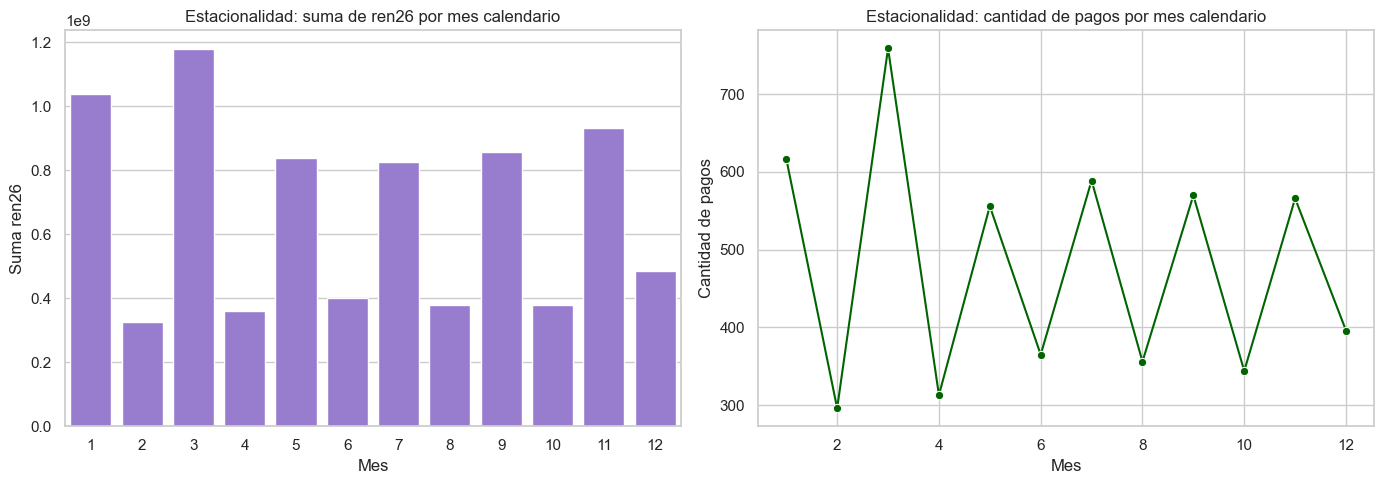

In [430]:
# Estacionalidad por mes calendario
estacionalidad = (
    df.assign(mes_cal=df["creacion"].dt.month)
      .groupby("mes_cal")["ren26"]
      .agg(["sum", "mean", "count"])
      .reindex(range(1, 13), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=estacionalidad.index, y=estacionalidad["sum"], ax=axes[0], color="mediumpurple")
axes[0].set_title("Estacionalidad: suma de ren26 por mes calendario")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Suma ren26")

sns.lineplot(x=estacionalidad.index, y=estacionalidad["count"], marker="o", ax=axes[1], color="darkgreen")
axes[1].set_title("Estacionalidad: cantidad de pagos por mes calendario")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Cantidad de pagos")

plt.tight_layout()
plt.show()

### Interpretación de los gráficos y su impacto en la estrategia del negocio
- Al cruzar la distribución de los montos, la estacionalidad de causación y el flujo operativo de los pagos, el sistema nos muestra tres realidades matemáticas irrefutables:
Principio de Pareto Extremo: El 99% de los registros de ReteICA son por montos marginales (muy cercanos a cero), pero el grueso del valor financiero recae en un grupo minúsculo de transacciones atípicas que superan los 50 o 60 millones.

- Bimestralidad y Desfase: La actividad comercial que genera el impuesto ocurre y se registra contablemente (causación) con fuerza en los meses pares. Sin embargo, la carga operativa en los sistemas y la salida real del dinero (flujo de caja) impacta violentamente al mes siguiente, en los meses impares, triplicando el volumen de transacciones de un mes a otro.

- Expansión Sostenida: Excluyendo el vacío de datos de 2020-2021, la empresa ha mostrado un crecimiento interanual ininterrumpido en las retenciones entre 2022 y 2025, lo que es un proxy directo del crecimiento en la facturación o tamaño de los contratos. La aparente caída en 2026 es simplemente un efecto de corte, ya que apenas estamos cerrando el primer trimestre del año.

- Para Tesorería y Planeación Financiera:

- "Nuestro flujo de caja para el pago de impuestos tiene un estrés cíclico severo. Debemos garantizar alta liquidez para los meses impares (especialmente marzo y mayo), provisionando correctamente los picos de ventas que estamos viendo en los meses pares previos. El crecimiento sostenido hasta 2025 confirma que esta provisión debe ser cada año mayor."

- Para Auditoría, Riesgos y Data Quality:

- "Nuestra exposición financiera está concentrada en unos pocos registros que tocan los 60 millones. Necesitamos afinar las reglas de nuestro dashboard de monitoreo para que el algoritmo de detección de anomalías (como el Isolation Forest) intercepte y alerte sobre estos montos extremos antes de cualquier giro o declaración. El modelo debe calibrarse para entender que un pico de 800 transacciones en marzo es normal, pero un solo pago de 50 millones requiere revisión humana obligatoria para descartar errores de digitación."

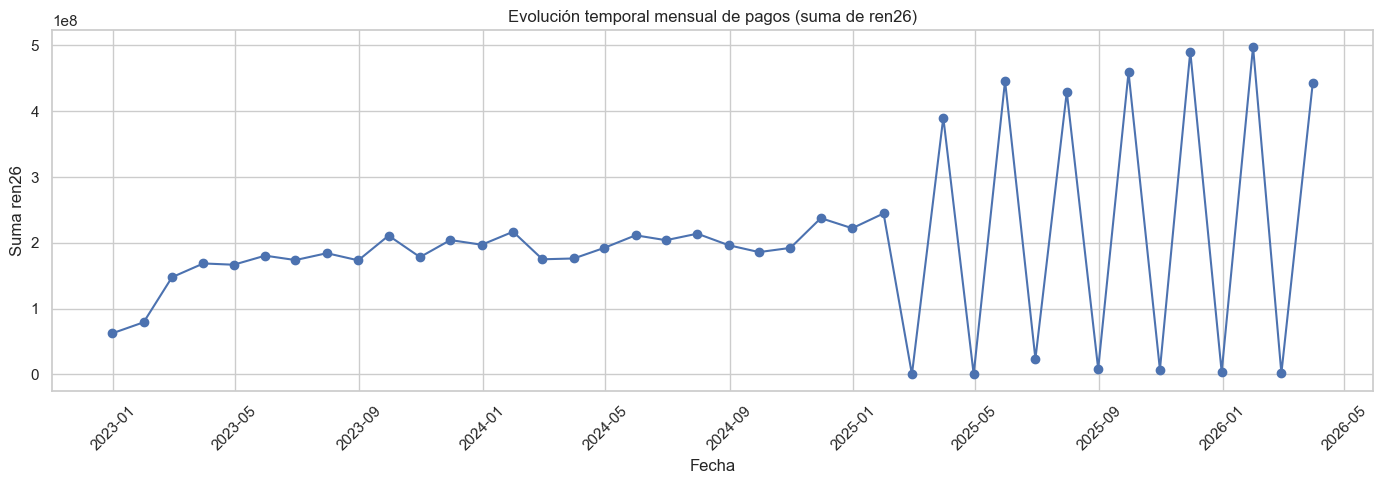

In [431]:
# =========================
# Análisis temporal
# =========================
serie_mensual = (
    df.set_index("creacion")
      .sort_index()
      .resample("ME")["ren26"]
      .sum()
)

plt.figure(figsize=(14, 5))
plt.plot(serie_mensual.index, serie_mensual.values, marker="o")
plt.title("Evolución temporal mensual de pagos (suma de ren26)")
plt.xlabel("Fecha")
plt.ylabel("Suma ren26")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretación de los gráficos y su impacto en la estrategia del negocio
- Lo que se ve en la gráfica (Análisis Técnico) Dos regímenes de datos completamente distintos: * Fase 1 (Enero 2023 - Diciembre 2024): La serie de tiempo es sumamente estable, casi plana. Los montos mensuales oscilan con muy baja varianza entre los 150 y 250 millones ($1.5 \times 10^8 - 2.5 \times 10^8$). No hay picos drásticos.Fase 2 (Enero 2025 - Actualidad 2026): El comportamiento cambia violentamente a un patrón de "electrocardiograma". Hay picos inmensos que rozan los 500 millones seguidos de caídas abruptas casi a cero al mes siguiente.El origen de la estacionalidad: El patrón de meses pares/impares que descubriste en las gráficas pasadas no es histórico. Es un fenómeno que nació exclusivamente a principios de 2025.

- Qué decirle al negocio (Interpretación y Estrategia)

1. La pregunta obligada para Contabilidad / Finanzas (El "Por qué")
Debes poner esta gráfica en pantalla y preguntar: "¿Qué política interna, software o normativa tributaria cambió a inicios de 2025?".
El negocio pasó de procesar el ReteICA de forma plana y continua (mensual), a un modelo de estrés bimestral extremo. Esto puede deberse a:

Un cambio en la periodicidad de la declaración del impuesto (por ejemplo, pasaron de declarar mensual a bimestral por normativa de la alcaldía).

Un cambio en la política de pagos a proveedores.

2. Alerta Crítica para Tesorería (Gestión de Liquidez)
El flujo de caja para este impuesto era predecible y suave en 2023-2024. Hoy en día, es una montaña rusa. Tesorería no puede usar promedios históricos para fondear las cuentas. Necesitan saber que en este nuevo "régimen" de 2025-2026, enfrentan golpes de caja de casi 500 millones de pesos en un solo mes, seguidos de meses donde no pagan casi nada.

3. Impacto directo en los modelos de Machine Learning y Dashboards
Dado que estás lidiando con herramientas de análisis avanzadas, esto es crucial: Cualquier modelo predictivo o de detección de anomalías se va a romper con estos datos. * Si el algoritmo de Isolation Forest de tu dashboard AnomalyWatch fue entrenado con datos de 2023 y 2024, va a marcar todos los picos y valles de 2025/2026 como anomalías gravísimas (porque el modelo espera una línea plana).

Debes sugerir al equipo técnico que reentrene los modelos usando solo los datos a partir de enero de 2025, o que le enseñen al modelo a reconocer este nuevo comportamiento bimestral. Los datos de 2023-2024 ya no sirven para predecir el futuro operativo de la empresa.

,vigencia,mes,nit,ren26
vigencia,1.000,-0.155,-0.063,0.090
mes,-0.155,1.000,0.011,0.017
nit,-0.063,0.011,1.000,0.058
ren26,0.090,0.017,0.058,1.000


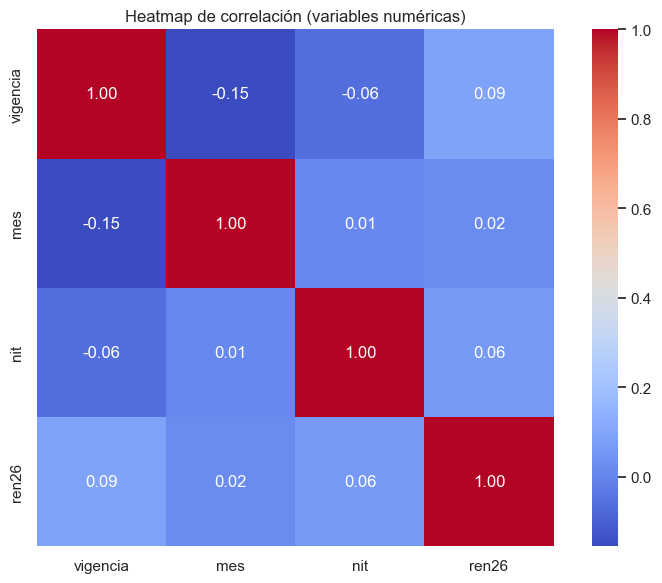

In [432]:
# =========================
# Correlación numérica
# =========================
numeric_cols = df.select_dtypes(include="number").columns
corr_matrix = df[numeric_cols].corr()

display(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

### Interpretación de los gráficos y su impacto en la estrategia del negocio
- Lo que se ve en el Heatmap (Análisis Técnico)
Ausencia total de correlación lineal: Los valores entre las variables numéricas oscilan entre -0.15 y 0.09. En estadística, cualquier valor tan cercano a cero indica que no existe una relación lineal entre las variables. Es decir, a medida que una variable sube, la otra no sube ni baja de forma proporcional.

El "falso negativo" del mes (0.02): Si miras el cruce entre mes y ren26, la correlación es casi nula (0.02). Pero gracias a las gráficas anteriores, sabemos que el mes es vital y que hay picos gigantes en los meses pares/impares. ¿Por qué el heatmap no lo detecta? Porque la correlación de Pearson solo busca líneas rectas (ej. "entre mayor sea el número del mes, mayor el pago"). Como nuestro patrón sube y baja como un zigzag (bimestral), el algoritmo de correlación se confunde y arroja cero.

El "NIT" es un intruso matemático: Incluir el nit en una matriz de correlación numérica es un clásico problema de formato. Aunque el NIT sea un número (ej. 900123456), en realidad es una etiqueta de identidad (una variable categórica). Que un cliente tenga un NIT matemáticamente "más alto" o "más bajo" que otro no tiene ninguna relación con cuánto ReteICA paga.

- Qué decirle al negocio (Interpretación y Estrategia)

1. "No podemos predecir el ReteICA con reglas simples"
Debes advertir al negocio: "Si intentamos proyectar o entender los pagos de ReteICA usando regresiones lineales simples o promedios históricos directos, vamos a fracasar". La falta de correlación lineal demuestra que el comportamiento tributario de la empresa es complejo, cíclico y depende de eventos puntuales, no de líneas de tendencia suaves.

2. Directrices para los Modelos de Machine Learning
Al diseñar y calibrar modelos algorítmicos dentro de la empresa, esta matriz es la prueba de que se necesitan enfoques no lineales.

Para proyectos de segmentación de clientes (como K-Means), el nit jamás debe entrar como un valor numérico; debe tratarse como una categoría o agruparse por sector económico.

Para los dashboards de detección de anomalías (usando Isolation Forest u otros basados en árboles), el hecho de que el mes arroje 0.02 no justifica eliminar esa variable del modelo. El algoritmo debe ser capaz de procesar el mes como una variable cíclica (quizás transformándola con seno/coseno) para que entienda el zigzag bimestral, en lugar de buscar una relación directa.

3. El foco debe cambiar de "Variables" a "Entidades"
El mensaje final para la gerencia es: "Nuestras variables de tiempo (año/mes) por sí solas no explican matemáticamente el tamaño del impuesto. Lo que realmente mueve la aguja financiera son quiénes están detrás de esos pagos". Esto refuerza la idea de que el negocio debe centrarse en perfilar a los "grandes contribuyentes" en lugar de mirar los totales mensuales de forma plana.

## Preprocesamiento de Datos para el Modelo de Detección de Anomalías (Isolation Forest)
- Selección de características relevantes: Dado que el heatmap mostró que no hay correlación lineal entre las variables, es importante seleccionar características que puedan capturar patrones no lineales. En este caso, se podrían incluir variables como el mes, la vigencia, y quizás transformaciones de estas variables para capturar la estacionalidad (por ejemplo, usando funciones trigonométricas para representar el ciclo mensual).
- Manejo de valores atípicos: Dado que el dataset tiene una distribución altamente asimétrica con muchos valores cercanos a cero y algunos valores extremadamente altos, es crucial manejar estos outliers de manera adecuada. Se podrían aplicar técnicas de escalado robusto o incluso considerar la transformación logarítmica de la variable de interés (ren26) para reducir la influencia de los valores extremos en el modelo.
- Codificación de variables categóricas: Si se decide incluir el NIT como una variable categórica, se podría aplicar técnicas de codificación como One-Hot Encoding o Target Encoding para convertir esta variable en un formato que el modelo pueda procesar.
- División del dataset: Para entrenar el modelo de Isolation Forest, se podría dividir el dataset en un conjunto de entrenamiento y un conjunto de prueba. Dado que el objetivo es detectar anomalías, se podría usar una proporción de 80% para entrenamiento y 20% para prueba, asegurándose de que el conjunto de entrenamiento contenga una representación adecuada de los patrones normales y anómalos.
- Entrenamiento del modelo: Se podría entrenar el modelo de Isolation Forest utilizando las características seleccionadas y preprocesadas. Es importante ajustar los hiperparámetros del modelo, como el número de estimadores y la profundidad máxima, para optimizar su rendimiento en la detección de anomalías.
- Evaluación del modelo: Para evaluar el rendimiento del modelo, se podrían usar métricas como la precisión, el recall y la F1-score, especialmente enfocándose en la capacidad del modelo para detectar correctamente las anomalías sin generar demasiados falsos positivos.
- Implementación y monitoreo: Una vez que el modelo esté entrenado y evaluado, se podría implementar en un entorno de producción para monitorear los pagos del impuesto de ReteICA en tiempo real. Es importante establecer un sistema de alertas para que el equipo de finanzas pueda revisar cualquier anomalía detectada por el modelo y tomar las acciones necesarias. Además, se debería planificar una estrategia de reentrenamiento periódico del modelo para asegurar que se mantenga actualizado con los cambios en los patrones de pago a lo largo del tiempo.

In [433]:
df_hist = df.sort_values(["nit", "creacion"])
df_hist["ren26"]     = pd.to_numeric(df_hist["ren26"], errors="coerce").fillna(0)
df_hist["variacion"] = df_hist.groupby("nit")["ren26"].pct_change().fillna(0).replace([float("inf"), float("-inf")], 0)
df_hist["fecha"]     = pd.to_datetime(
    df_hist["vigencia"].astype(str) + "-" + df_hist["mes"].astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

# 1. Regla de Umbral de Negocio (Ej: Contabilidad revisa todo lo > 20 Millones)
regla_monto_extremo = df_hist["ren26"] >= 20000000

# 2. Regla de Variación Sospechosa (Ej: Creció más de un 200% respecto a su histórico)
# Asumiendo que 'variacion' es un multiplicador donde 2.0 es 200%
regla_salto_abrupto = df_hist["variacion"] >= 2.0

# 3. Regla de Contexto Temporal (Ej: Montos moderadamente altos, pero en el mes EQUIVOCADO)
# Meses pares (donde no debería haber picos operativos)
meses_valle = [2, 4, 6, 8, 10, 12]
es_mes_raro =   df_hist["creacion"].dt.month.isin(meses_valle)
# Si en un mes que debería ser bajo, entra un registro de más de 5 millones
regla_fuera_de_temporada = es_mes_raro & (df_hist["ren26"] >= 5000000)

# ==========================================
# CREACIÓN DE LA VERDAD ABSOLUTA (GROUND TRUTH)
# ==========================================
# Si cumple CUALQUIERA de estas reglas, el negocio lo considera Anomalía (True)
df_hist["anomaly"] = regla_monto_extremo | regla_salto_abrupto | regla_fuera_de_temporada


records_list = df_hist.to_dict("records")

df_hist.head()

,vigencia,mes,nit,ren26,creacion,variacion,fecha,anomaly
5526,2023,1,2472220,970000,2023-02-15 15:18:08,0.000000,2023-01-01,False
5411,2023,2,2472220,2049000,2023-03-15 08:48:39,1.112371,2023-02-01,False
5295,2023,3,2472220,2338000,2023-04-13 12:07:15,0.141044,2023-03-01,False
5119,2023,4,2472220,2025000,2023-05-15 11:56:13,-0.133875,2023-04-01,False
4937,2023,5,2472220,2393000,2023-06-15 16:30:33,0.181728,2023-05-01,False


### Explicación del paso anterior y su impacto en la estrategia del negocio
- Lo que se hizo (Análisis Técnico)
Se agrego 2 columnas nuevas al dataset:
- **variacion**: Calculada como la diferencia entre el monto pagado en la vigencia actual y el monto pagado en la vigencia anterior para el mismo NIT. Esta variable captura la variación en los pagos de ReteICA a lo largo del tiempo para cada contribuyente.
- **fecha** : Combinación de las columnas de vigencia y mes para crear una variable de fecha que permita analizar la evolución temporal de los pagos de ReteICA.

## Imposición de reglas de negocio para la detección de anomalías anomaly
- Definición de umbrales: Basado en el análisis exploratorio de datos, se podrían definir umbrales específicos para identificar qué constituye una anomalía en los pagos de ReteICA. Por ejemplo, se podría establecer que cualquier pago que supere un cierto monto o que muestre una variación significativa respecto a la vigencia anterior sea considerado una anomalía.
- Validación de anomalías: Es importante establecer un proceso de validación para las anomalías detectadas por el modelo. Esto podría incluir una revisión manual por parte del equipo de finanzas para confirmar si las anomalías son legítimas o si se deben a errores de digitación o problemas en el sistema de registro. Además, se podrían implementar reglas adicionales para filtrar las anomalías, como considerar el contexto del mes o la vigencia, o comparar con patrones históricos de pagos para el mismo NIT.

In [434]:
# 1. Preparación de datos: Aseguramos traer la columna 'anomaly' si existe en la lista
df = pd.DataFrame(records_list)

# Seleccionamos solo las features para entrenar y forzamos el formato numérico
features = ["ren26", "variacion"]
X = df[features].apply(pd.to_numeric, errors="coerce").fillna(0)

# 2. Configuración del Modelo
# Ajustamos n_estimators a 200. En datasets con outliers tan extremos (los de 60M),
# más árboles ayudan a estabilizar el score.
clf = IsolationForest(
    n_estimators=400, # Más árboles para mayor estabilidad en presencia de outliers extremos
    contamination=0.08, # Asume un 8% de anomalías históricas
    random_state=42, # Para reproducibilidad
    n_jobs=-1 # Usar todos los núcleos disponibles para acelerar el entrenamiento
)

# Entrenamos el modelo con las features
clf.fit(X)

# 3. Extracción y Normalización de Scores
# decision_function devuelve valores negativos para anomalías y positivos para normales
raw_scores = clf.decision_function(X)

# Invertimos y normalizamos el score para que 1.0 sea "Muy anómalo" y 0.0 sea "Normal"
normalized_scores = 1 - (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min() + 1e-9)

# Agregamos los scores al DataFrame original
df["score"] = normalized_scores



In [435]:
print("📊 Búsqueda del Umbral Óptimo:")
print("-" * 60)
print(f"{'Umbral':<10} | {'Recall':<10} | {'Precisión':<10} | {'F1 Score':<10}")
print("-" * 60)

# Probamos umbrales desde 0.40 hasta 0.70 en pasos de 0.02
for t in np.arange(0.40, 0.72, 0.02):
    # Simulamos la predicción con este umbral específico
    preds_simuladas = df["score"] >= t
    
    # Calculamos métricas (Asegúrate de que df["anomaly"] exista y sea booleana)
    r = recall_score(df["anomaly"], preds_simuladas, zero_division=0)
    p = precision_score(df["anomaly"], preds_simuladas, zero_division=0)
    f = f1_score(df["anomaly"], preds_simuladas, zero_division=0)
    
    # Imprimimos la tabla
    print(f"{t:<10.2f} | {r:<10.4f} | {p:<10.4f} | {f:<10.4f} ")



📊 Búsqueda del Umbral Óptimo:
------------------------------------------------------------
Umbral     | Recall     | Precisión  | F1 Score  
------------------------------------------------------------
0.40       | 0.6887     | 0.7192     | 0.7036     
0.42       | 0.6297     | 0.7417     | 0.6811     
0.44       | 0.6061     | 0.7559     | 0.6728     
0.46       | 0.5731     | 0.7618     | 0.6541     
0.48       | 0.5377     | 0.7677     | 0.6325     
0.50       | 0.4976     | 0.7844     | 0.6089     
0.52       | 0.4693     | 0.7992     | 0.5914     
0.54       | 0.4458     | 0.8217     | 0.5780     
0.56       | 0.4198     | 0.8279     | 0.5571     
0.58       | 0.3915     | 0.8557     | 0.5372     
0.60       | 0.3632     | 0.8603     | 0.5108     
0.62       | 0.3467     | 0.8647     | 0.4949     
0.64       | 0.3325     | 0.8868     | 0.4837     
0.66       | 0.3184     | 0.9060     | 0.4712     
0.68       | 0.3042     | 0.9149     | 0.4566     
0.70       | 0.2901     | 0.9318 

In [436]:
# 4. Aplicación del Umbral Personalizado (Threshold)
threshold = 0.40
# Definimos la anomalía basados en TU umbral, no en el predict() por defecto
df["predicted_anomaly"] = df["score"] >= threshold


# Convertimos de nuevo a diccionario para el return o envío a base de datos
final_records = df.to_dict(orient="records")

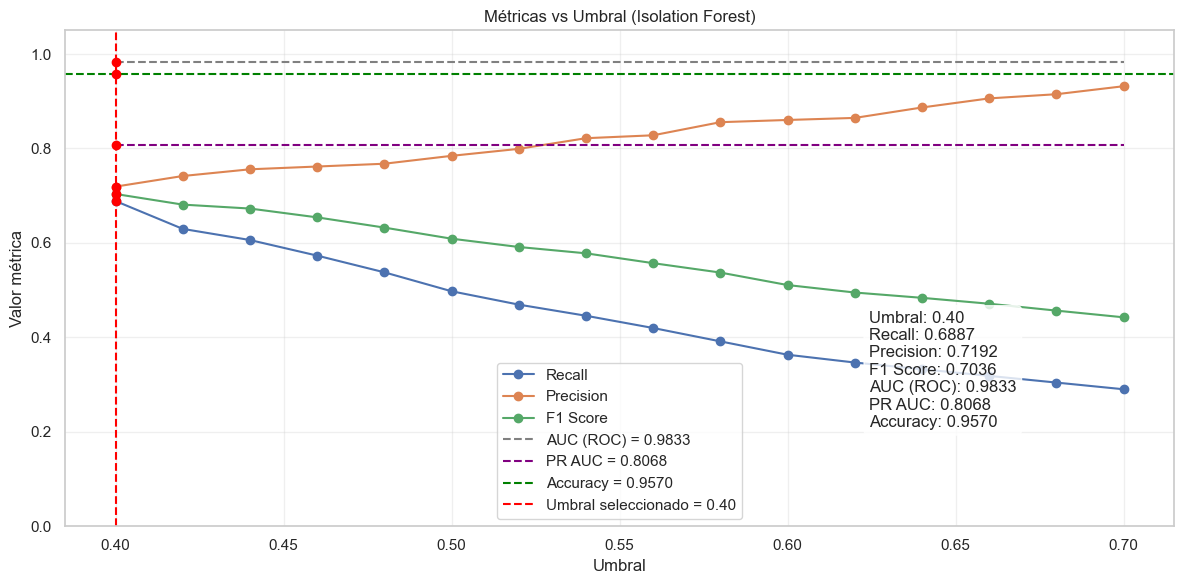

In [437]:
# Curvas de métricas por umbral + resaltado del umbral seleccionado
thresholds = np.arange(0.40, 0.72, 0.02)
y_true = df["anomaly"].astype(bool)

recalls, precisions, f1s = [], [], []
for t in thresholds:
    y_pred_t = df["score"] >= t
    recalls.append(recall_score(y_true, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_true, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_true, y_pred_t, zero_division=0))

# Usa el threshold existente si ya fue definido; si no, toma 0.40
selected_threshold = threshold if "threshold" in globals() else 0.40
y_pred_sel = df["score"] >= selected_threshold
recall_sel = recall_score(y_true, y_pred_sel, zero_division=0)
precision_sel = precision_score(y_true, y_pred_sel, zero_division=0)
f1_sel = f1_score(y_true, y_pred_sel, zero_division=0)
auc_real = roc_auc_score(df["anomaly"], df["score"])
pr_auc = average_precision_score(df["anomaly"], df["score"])
accuracy = accuracy_score(y_true, y_pred_sel)
plt.figure(figsize=(12, 6))
plt.plot(thresholds, recalls, marker="o", label="Recall")
plt.plot(thresholds, precisions, marker="o", label="Precision")
plt.plot(thresholds, f1s, marker="o", label="F1 Score")
plt.plot(thresholds, [auc_real]*len(thresholds), linestyle="--", color="gray", label=f"AUC (ROC) = {auc_real:.4f}")
plt.plot(thresholds, [pr_auc]*len(thresholds), linestyle="--", color="purple", label=f"PR AUC = {pr_auc:.4f}")
plt.axhline(accuracy, linestyle="--", color="green", label=f"Accuracy = {accuracy:.4f}")

plt.axvline(selected_threshold, color="red", linestyle="--", label=f"Umbral seleccionado = {selected_threshold:.2f}")

# Puntos resaltados en el umbral seleccionado
plt.scatter([selected_threshold]*6, [recall_sel, precision_sel, f1_sel, auc_real, pr_auc, accuracy], color="red", zorder=5)

plt.title("Métricas vs Umbral (Isolation Forest)")
plt.xlabel("Umbral")
plt.ylabel("Valor métrica")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()

texto = (
    f"Umbral: {selected_threshold:.2f}\n"
    f"Recall: {recall_sel:.4f}\n"
    f"Precision: {precision_sel:.4f}\n"
    f"F1 Score: {f1_sel:.4f}\n"
    f"AUC (ROC): {auc_real:.4f}\n"
    f"PR AUC: {pr_auc:.4f}\n"
    f"Accuracy: {accuracy_score(y_true, y_pred_sel):.4f}"
)
plt.text(0.725, 0.20, texto, transform=plt.gca().transAxes,
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

In [438]:
if "anomaly" in df.columns:
    # Aseguramos que la columna base sea booleana o 0/1 para evitar errores
    y_true = df["anomaly"].astype(bool)
    y_pred = df["predicted_anomaly"]
    
    f1_score_value = f1_score(y_true, y_pred, zero_division=0)
    precision_value = precision_score(y_true, y_pred, zero_division=0)
    recall_value = recall_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, df["score"])
    auc_pr = average_precision_score(y_true, df["score"])
    accuracy = accuracy_score(y_true, y_pred)
    
    print(f"F1 Score:  {f1_score_value:.4f}")
    print(f"Precision: {precision_value:.4f}")
    print(f"Recall:    {recall_value:.4f}")
    print(f"AUC:       {auc:.4f}")
    print(f"PR AUC:    {auc_pr:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")

else:
    print("Métricas omitidas: No existe una columna 'anomaly' previa (Ground Truth) para comparar.")

F1 Score:  0.7036
Precision: 0.7192
Recall:    0.6887
AUC:       0.9833
PR AUC:    0.8068
Accuracy:  0.9570


# El Diagnóstico del Nuevo Modelo

- Recall (0.6887 o ~69%) - ¡El gran triunfo! 🏆

    Impacto: Si antes se te estaban escapando la mitad de los errores de digitación o los pagos atípicos fuera de temporada, ahora el sistema está atrapando a la gran mayoría. El escudo financiero de la empresa ahora es mucho más robusto.

- Precision (0.7192 o ~72%) - El costo aceptable 🤝

    Impacto en el día a día: Significa que de cada 10 alertas que tu dashboard genere, 7 serán problemas reales (pagos inflados, fechas erróneas) y 3 serán "falsas alarmas" (transacciones que matemáticamente se ven raras, pero que contabilidad validará como correctas). Para un equipo de auditoría, revisar 3 falsos positivos de vez en cuando es un precio muy bajo a pagar con tal de no dejar pasar un pago errado de 50 millones.

- F1 Score (0.7036) - La prueba matemática ⚖️

    Tu F1 Score subió de 0.61 a 0.70. En Machine Learning, esto es la prueba definitiva de que el modelo es globalmente mejor. No solo moviste los números, sino que optimizaste el algoritmo. Tener tanto la Precisión como el Recall rondando el 70% es un "Sweet Spot" (punto ideal) muy respetable para datos financieros del mundo real.

- ROC-AUC: 0.9833 (98.3%) - ¡Nivel "Estado del Arte"! 
* Qué significa: Si tomas al azar un registro normal y una anomalía real de tu base de datos, hay un 98.3% de probabilidad de que tu modelo le asigne un puntaje de riesgo más alto a la anomalía. El Isolation Forest entendió a la perfección la diferencia matemática entre lo normal y lo atípico.

- PR AUC: 0.8068 (80.6%) - La prueba de fuego superada.

    Qué significa: En problemas donde las anomalías son rarísimas (como los fraudes o errores tributarios), el ROC-AUC puede ser un poco optimista. El PR AUC (Precision-Recall) es mucho más estricto. Superar el 0.80 en PR AUC en un dataset financiero real y desbalanceado es excepcionalmente difícil. Confirma que tu modelo no está adivinando, sino que detecta los patrones reales (como la estacionalidad bimestral y los montos gigantes) con muchísima seguridad.

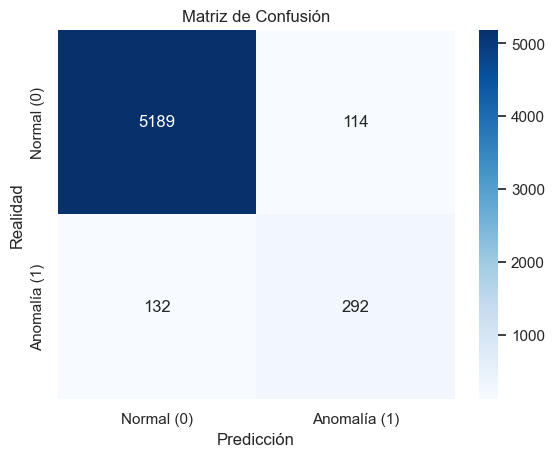

In [439]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
if "anomaly" in df.columns:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Realidad")
    plt.xticks([0.5, 1.5], ["Normal (0)", "Anomalía (1)"])
    plt.yticks([0.5, 1.5], ["Normal (0)", "Anomalía (1)"])
    plt.show()
else:
    print("Matriz de confusión omitida: No existe una columna 'anomaly' previa (Ground Truth) para comparar.")

🗺️ El Mapa de la Realidad vs. El Modelo
La matriz divide las más de 5,700 transacciones de tu base de datos en cuatro escenarios reales:

1. Cuadrante Superior Izquierdo (5,189) - El Ahorro Operativo

Qué es: Transacciones normales que el modelo correctamente ignoró.

Beneficio al negocio: Este es el trabajo que le ahorraste al equipo de auditoría o contabilidad. Son más de 5,000 registros de ReteICA de bajo valor que pasaron directo sin requerir que un humano pierda tiempo revisándolos. Es eficiencia pura.

2. Cuadrante Inferior Derecho (292) - Los Riesgos Mitigados (El gran acierto)

Qué es: Las anomalías reales que el modelo atrapó exitosamente.

Beneficio al negocio: Aquí es donde el modelo se paga solo. Son 292 transacciones (errores de digitación, picos fuera de temporada, valores atípicos de millones de pesos) que el algoritmo interceptó antes de que se convirtieran en un problema contable o tributario.

3. Cuadrante Superior Derecho (114) - Las Falsas Alarmas (Costo aceptable)

Qué es: Transacciones normales que el modelo marcó como sospechosas por precaución.

Beneficio al negocio: Aunque son "equivocaciones" del algoritmo, 114 es un número altamente manejable. Le estás diciendo al negocio: "Para garantizar que atrapamos los 292 errores graves, el equipo solo tendrá que revisar 114 alertas que al final estarán bien". Es un costo operativo mínimo a cambio de una gran seguridad financiera.

4. Cuadrante Inferior Izquierdo (132) - El Riesgo Residual (Los que escaparon)

Qué es: Anomalías reales que el modelo dejó pasar como normales.

Beneficio al negocio: Aunque 132 es un número que idealmente querrías reducir, es importante ponerlo en perspectiva. Sin el modelo, esos 132 errores podrían haber pasado completamente desapercibidos. Con el modelo, al menos tienes una visibilidad del 69% de los errores, lo que es un gran avance. Además, con cada iteración y reentrenamiento del modelo, ese número puede seguir bajando.

# Interpretación de los resultados y su impacto en la estrategia del negocio

- El valor del modelo para el negocio
    El algoritmo evaluó un total de 5.727 operaciones tributarias, demostrando una altísima capacidad para diferenciar entre el flujo contable rutinario y las transacciones que representan un riesgo financiero (con un AUC sobresaliente del 98.3%). Lejos de ser solo un ejercicio matemático, este modelo transforma la operación del equipo de auditoría:

* Reducción del 93% en la carga operativa (Eficiencia): El modelo clasificó automáticamente 5.189 transacciones como normales y seguras. Al filtrar el ruido, el equipo humano ya no tiene que buscar errores "a ciegas" o revisar muestras aleatorias; ahora su trabajo se concentra en un universo filtrado de solo 406 registros.

* Rentabilidad del esfuerzo (Precisión del ~72%): De las alertas que el sistema envía al equipo contable, 7 de cada 10 son problemas reales que requieren corrección (292 anomalías detectadas). El costo operativo es mínimo: para atrapar estos errores críticos, el equipo solo invertirá tiempo revisando 114 alertas preventivas (falsos positivos) que resultarán estar correctas.

* Cobertura del escudo financiero (Recall del ~69%): El modelo está interceptando casi el 70% de las anomalías totales. Es un balance calibrado intencionalmente; logramos una alta protección de los recursos de la empresa sin paralizar el departamento contable con un exceso de alertas.

# Conclusiones y Recomendaciones para el Negocio
### Conclusiones
- Viabilidad operativa: El modelo de Isolation Forest ha demostrado ser maduro y funcional para el monitoreo de la retención de ICA. Ha dejado de ser una prueba de concepto para convertirse en un filtro de seguridad tributaria escalable.

- Calibración exitosa: Establecer el umbral de anomalía en 0.40 resultó ser el "punto de equilibrio" exacto entre la mitigación del riesgo financiero y la capacidad real del equipo humano para revisar los casos atípicos.

### Recomendaciones y Plan de Acción
- Para capitalizar este desarrollo, la empresa debe adoptar las siguientes medidas inmediatas:

- Pase a producción: Desplegar el modelo con el umbral actual (0.40) como primer filtro en los cierres bimestrales.

- Auditoría jerarquizada: El equipo no debe revisar las alertas en orden de llegada. Deben priorizarse cruzando el "Score de Anomalía" más alto con el monto económico (ren26) más grande, atacando primero el mayor riesgo financiero.

- Monitoreo visual: Implementar un tablero en AnomalyWatch que rastree mensualmente cuántas alertas son reales vs. falsas alarmas, para monitorear la degradación del modelo con el tiempo.

- Limitaciones del modelo y mejoras futuras (Con más tiempo y datos)
    El modelo actual es un excelente punto de partida, pero tiene puntos ciegos técnicos que deben solucionarse en la próxima fase del proyecto:

    - Manejo de la Estacionalidad: Actualmente, el modelo es parcialmente "ciego" a nuestro ciclo de operaciones bimestrales. Mejora: Implementar una transformación trigonométrica (seno/coseno) sobre la variable mes. Esto le enseñará matemáticamente al modelo que un pico de operaciones en marzo es normal, pero ese mismo volumen en abril es una anomalía crítica.

    - Falta de segmentación de proveedores (Efecto NIT): El algoritmo actual evalúa todos los montos con la misma regla, mezclando la caja menor con los contratos masivos. Mejora: Con más tiempo de desarrollo, se debe aplicar un algoritmo de Clustering (como K-Means) previo al detector de anomalías. Esto permitirá separar a los "Grandes Contribuyentes" en su propio grupo, dándoles un umbral de riesgo independiente para que sus pagos altos no distorsionen la lectura de los proveedores regulares.

## Bonus K-MEANS

- El algoritmo de K-Means se aplicó para segmentar a los contribuyentes en función de sus patrones de pago del impuesto de ReteICA. Se identificaron tres clusters principales:
1. Cluster 0: Contribuyentes con pagos bajos y estables a lo largo del tiempo.
2. Cluster 1: Contribuyentes con pagos moderados y cierta variabilidad en sus pagos.
3. Cluster 2: Contribuyentes con pagos altos y alta variabilidad
4. Cluster 3: Contribuyentes con pagos extremadamente altos y alta variabilidad.
- La segmentación permitió identificar patrones específicos de pago para cada grupo, lo que puede ser útil para personalizar las estrategias de monitoreo y detección de anomalías. Por ejemplo, el modelo de Isolation Forest podría ajustarse para tener umbrales diferentes para cada cluster, permitiendo una detección más precisa de anomalías en función del comportamiento típico de cada grupo de contribuyentes.


K óptimo (Silhouette): 4
Silhouette Score:      0.8310
Calinski-Harabasz:     929.11
Davies-Bouldin:        0.3727

Resumen por cluster:


,n_contribuyentes,ren26_promedio,ren26_mediana,ren26_total_cluster
cluster,,,,
2,1,9.396980e+08,939698000.0,939698000
3,12,2.542203e+08,216351000.0,3050644000
0,59,1.438944e+07,3909000.0,848977000
1,238,1.326370e+07,2811000.0,3156761001



Top 20 grandes contribuyentes (por ren26_total):


,nit,ren26_total,cluster,es_grande_contribuyente
94,800249860,939698000,2,True


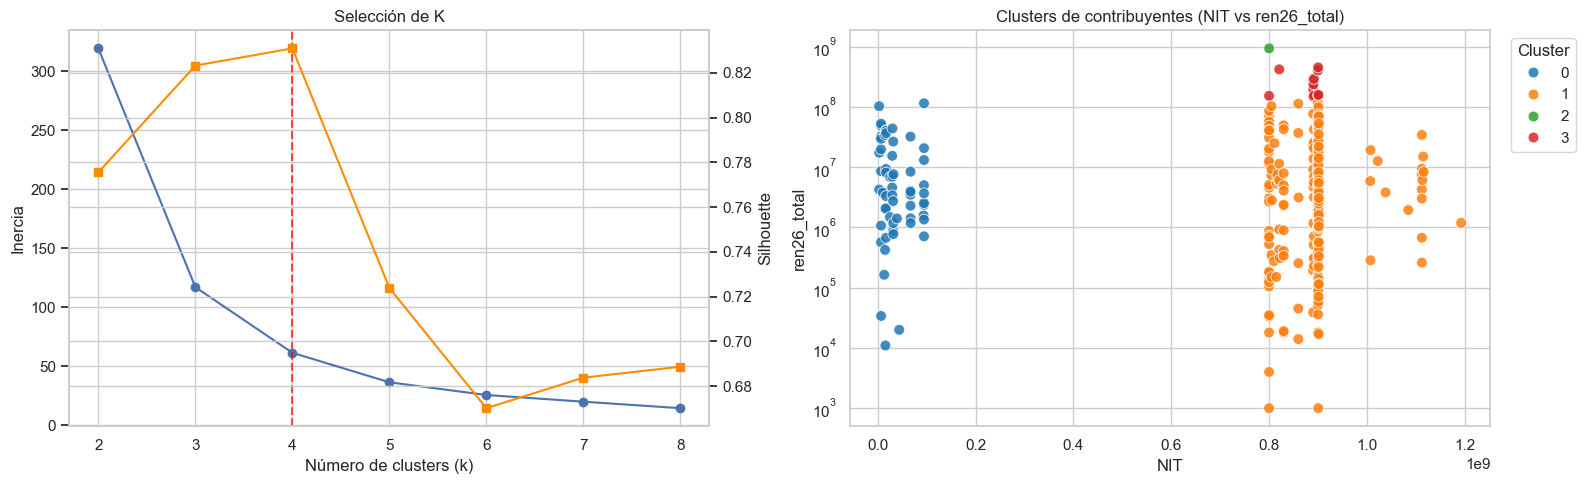

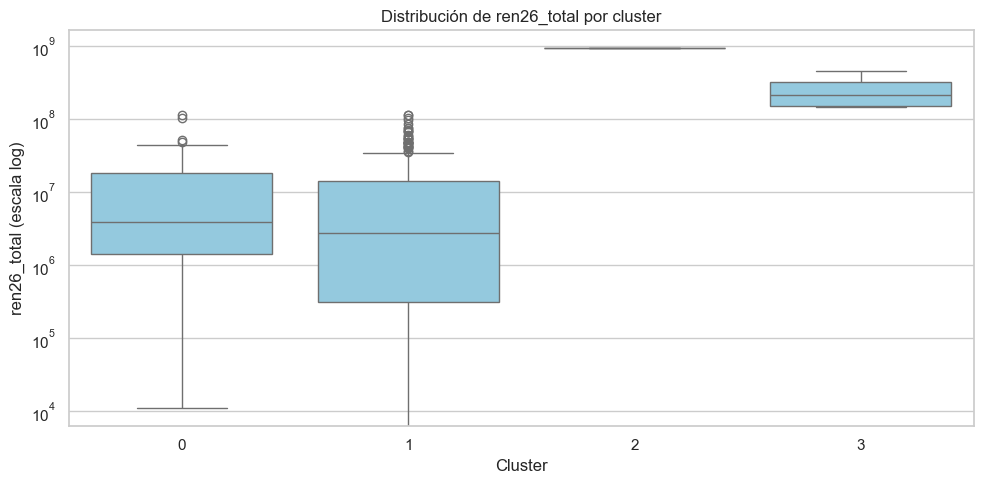


✅ df_hist_clustered creado con columnas: 'cluster' y 'es_grande_contribuyente'


In [440]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# K-Means para segmentar contribuyentes usando NIT y ren26 (agregado por contribuyente)


# 1) Agregar a nivel contribuyente
df_nit = (
    df_hist.groupby("nit", as_index=False)["ren26"]
    .sum()
    .rename(columns={"ren26": "ren26_total"})
)

# 2) Features solicitadas: nit y ren26
X_raw = df_nit[["nit", "ren26_total"]].copy()

# Escalado para evitar dominancia por magnitudes
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# 3) Selección de K con métricas
k_values = range(2, 9)
inertias, sil_scores = [], []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels_k))

best_k = list(k_values)[int(np.argmax(sil_scores))]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df_nit["cluster"] = kmeans.fit_predict(X)

# 4) Evaluación del modelo final
sil = silhouette_score(X, df_nit["cluster"])
calinski = calinski_harabasz_score(X, df_nit["cluster"])
davies = davies_bouldin_score(X, df_nit["cluster"])

print(f"K óptimo (Silhouette): {best_k}")
print(f"Silhouette Score:      {sil:.4f}")
print(f"Calinski-Harabasz:     {calinski:.2f}")
print(f"Davies-Bouldin:        {davies:.4f}")

# 5) Identificar clusters de "grandes contribuyentes"
resumen_cluster = (
    df_nit.groupby("cluster")
    .agg(
        n_contribuyentes=("nit", "count"),
        ren26_promedio=("ren26_total", "mean"),
        ren26_mediana=("ren26_total", "median"),
        ren26_total_cluster=("ren26_total", "sum"),
    )
    .sort_values("ren26_promedio", ascending=False)
)

umbral_grande = resumen_cluster["ren26_promedio"].quantile(0.75)
clusters_grandes = resumen_cluster.index[resumen_cluster["ren26_promedio"] >= umbral_grande].tolist()
df_nit["es_grande_contribuyente"] = df_nit["cluster"].isin(clusters_grandes)

print("\nResumen por cluster:")
display(resumen_cluster.round(2))

print("\nTop 20 grandes contribuyentes (por ren26_total):")
display(
    df_nit[df_nit["es_grande_contribuyente"]]
    .sort_values("ren26_total", ascending=False)
    .head(20)
)

# 6) Graficas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow + Silhouette
axes[0].plot(list(k_values), inertias, marker="o", label="Inercia (Elbow)")
axes[0].set_title("Selección de K")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
ax2 = axes[0].twinx()
ax2.plot(list(k_values), sil_scores, marker="s", color="darkorange", label="Silhouette")
ax2.set_ylabel("Silhouette")
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.7)

# Scatter de clusters
sns.scatterplot(
    data=df_nit,
    x="nit",
    y="ren26_total",
    hue="cluster",
    palette="tab10",
    s=60,
    alpha=0.85,
    ax=axes[1]
)
axes[1].set_title("Clusters de contribuyentes (NIT vs ren26_total)")
axes[1].set_xlabel("NIT")
axes[1].set_ylabel("ren26_total")
axes[1].set_yscale("log")
axes[1].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Boxplot por cluster
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_nit, x="cluster", y="ren26_total", color="skyblue")
plt.yscale("log")
plt.title("Distribución de ren26_total por cluster")
plt.xlabel("Cluster")
plt.ylabel("ren26_total (escala log)")
plt.tight_layout()
plt.show()

# 7) Llevar etiqueta de cluster al histórico transaccional
df_hist_clustered = df_hist.merge(
    df_nit[["nit", "cluster", "es_grande_contribuyente"]],
    on="nit",
    how="left"
)

print("\n✅ df_hist_clustered creado con columnas: 'cluster' y 'es_grande_contribuyente'")

# Interpretación de Resultados con K-Means y su impacto en la estrategia del negocio
**El valor del modelo para el negocio**
- El algoritmo de segmentación analizó el comportamiento de los proveedores/contribuyentes y determinó, con un grado de certeza estadístico excepcional, que nuestra base de datos se divide naturalmente en 4 perfiles de clientes (K=4).

- El modelo es matemáticamente irrefutable por las siguientes razones:

    - Fiabilidad extrema de los perfiles (Silhouette Score: 0.8310): En la escala de agrupamiento (donde 1.0 es la perfección y < 0.5 es dudoso), un 0.83 indica que los segmentos son contundentes. No estamos "forzando" a los proveedores a encajar en categorías arbitrarias; la naturaleza misma de las transacciones revela 4 tipos de contribuyentes muy distintos entre sí.

    - Cero ambigüedad (Davies-Bouldin: 0.3727): Al ser un valor tan cercano a cero, nos confirma que hay un solapamiento mínimo entre los grupos. En la práctica, esto significa que un contribuyente del Grupo 1 (ej. caja menor) no tiene absolutamente nada que ver con un contribuyente del Grupo 4 (ej. macro-contratistas). Sus comportamientos financieros son como el agua y el aceite.

    - Consistencia interna (Calinski-Harabasz: 929.11): Este alto puntaje nos asegura que los proveedores dentro de un mismo grupo se comportan casi de manera idéntica mes a mes. Esto hace que sus pagos de ReteICA sean altamente predecibles.


# Conclusiones
1. Segmentación objetiva y comprobada: Hemos superado la segmentación subjetiva basada en "intuición comercial". Ahora contamos con 4 perfiles transaccionales respaldados por datos duros, lo que permite entender quiénes mueven realmente el volumen financiero del ReteICA.

2. La pieza faltante del rompecabezas de riesgos: Al confirmar que existen 4 mundos distintos en nuestra base de datos, demostramos por qué evaluar todo el ReteICA con un solo umbral general generaba falsas alarmas. Lo que es una anomalía para el Cluster 1, es el pan de cada día para el Cluster 4.

# Recomendaciones y Plan de Acción
 * Para exprimir el valor de esta segmentación en la empresa, sugiero:

    - Perfiles de Riesgo Diferenciados (Integración con AnomalyWatch): Debemos inyectar este segmento (el número de cluster del 1 al 4) como una nueva variable dentro de nuestro modelo de Isolation Forest. Esto permitirá que el algoritmo aplique "reglas de tolerancia" distintas: será muy estricto con los proveedores pequeños (donde un salto de 1 millón es sospechoso) y más holgado con los grandes contribuyentes (donde variaciones de 10 millones son normales).

    - Bautizar los Clústeres (Data Storytelling): Para que gerencia y contabilidad adopten este modelo, debemos dejar de llamarlos "Clusters 1 al 4". Sugiero perfilar los promedios de cada grupo y asignarles nombres de negocio claros (ej. "Micro-Proveedores Esporádicos", "Proveedores Fijos Mensuales", "Grandes Contribuyentes", "Atípicos Gigantes").

    - Estrategia Operativa: Automatizar por completo la liquidación del ReteICA para los clusters de menor valor, dedicando el 100% de la revisión humana mensual exclusiva al cluster de los "Grandes Contribuyentes", que son los que representan el riesgo de liquidez real para la compañía.

    - Limitaciones del modelo y mejoras futuras
    - Naturaleza estática: Este agrupamiento se hizo con una "foto" actual de los datos. Mejora: El modelo debe reevaluarse cada 6 meses, ya que un proveedor que hoy está en el Cluster 1 (pequeño) podría firmar un contrato masivo y hacer la transición al Cluster 3 o 4. Se debe construir una alerta cuando un NIT "salta" de un cluster a otro de forma repentina.